# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Anisya Lutfiyani
- **Email:** 18lutfiyani@gmail.com
- **ID Dicoding:** CDCC476D6X1227

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir?

- Pertanyaan 2 : Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from babel.numbers import format_currency
sns.set(style='dark')
import datetime as dt

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
pandas
numpy
matplotlib
seaborn
babel""")

In [4]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Wrangling

### Gathering Data

In [5]:
# Load data
orders = pd.read_csv('/content/drive/MyDrive/data/orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/data/order_items_dataset.csv')  # FIX
customers = pd.read_csv('/content/drive/MyDrive/data/customers_dataset.csv')

In [6]:
# Merge orders
df = pd.merge(
    orders,
    order_items,
    how='inner',
    on='order_id'
)

# Merge dengan customers
df = pd.merge(
    df,
    customers,
    how="inner",
    on="customer_id"
)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


**Insight:**
- load data : berdasarkan proses data gathering, menunjukan bahwa data transaksi tersebar dalam beberapa tabel yang saling berelasi melalui key seperti order_id dan customer_id. struktur data terpisah, mengidinkasikan bahwa diperlukan merge untuk memperoleh dataset yang utuh sebelu, dilakukan analisis lebih lanjut.
- merge : hasil penggabungan menunjukan bahwa data transaksi, detail produk, dan informasi pelanggan diintegrasikan ke dalam satu dataset yang utuh. jumlah baris dataset ini menyediakan informasi lengkap yang dapat digunakan untuk menganalisis tren penjualan serta perlaku pembelian pelanggan secara lebih komprehensif    

### Assessing Data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

melakukan pengecekan struktur data untuk mengetahui jumlah baris, jumlah kolom serta tipe data dari setiap kolom pada dataset hasil penggabungan.

In [8]:
df.describe()

,order_item_id,price,freight_value,customer_zip_code_prefix
count,112650.000000,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320,35119.309090
std,0.705124,183.633928,15.806405,29866.120801
min,1.000000,0.850000,0.000000,1003.000000
25%,1.000000,39.900000,13.080000,11310.000000
50%,1.000000,74.990000,16.260000,24340.000000
75%,1.000000,134.900000,21.150000,59028.750000
max,21.000000,6735.000000,409.680000,99990.000000


statistik deskriptif menunjukan adanya variasi nilai pada kolom harga (price), yag mengindikasikan perbedaan nilai transaksi antar pelanggan

In [9]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1194
order_delivered_customer_date,2454
order_estimated_delivery_date,0
order_item_id,0
product_id,0


**Insight:**
- kelengkapan data pada kolom utama seperti price dan order_id menunjukkan bahwa dataset cukup reliabel untuk analisis performa penjualan namun analisis terkait penngiriman perlu mempertimbangkan adanya missing value pada kolom waktu pengiriman

### Cleaning Data

In [10]:
df.drop(columns=['order_delivered_carrier_date',
                 'order_delivered_customer_date'
], inplace=True, errors='ignore')

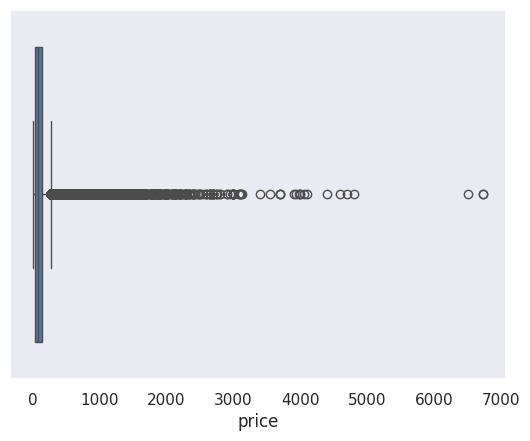

In [11]:
#teknik untuk mengatasi outlier
sns.boxplot(x=df['price'])
plt.show()

In [12]:
#drop duplicated
#mengecek duplikat
df.duplicated().sum()

np.int64(0)

**Insight:**
- sebagian besar data tidak memiliki missing value, namun terdapat kekosongan pada kolom terkait pengiriman seperti order_delivered_customer_date dan order_delivered_date. hal ini memungkinkan disebabkan oleh pesanan yang belum selesai atau dibatalkan. oleh karena itu perlu diperlakukan penanganan pada kolom tersebut.

- berdasarkan visualisasi boxplot pada kolom price, menunjukkan bahwa mayoritas berasa pada rentang harga rendah, sementara terdapat sejumlah kecil transaksi dengan nilai yang sangat tinggi. outlier ini menyebabkan distribusi data menjadi tidak simetris, yang dapat memengaruhi analisis statistik seperti rata-rata, outlier tidak dohapus karena dianggap sebagai bagian dari variasi harga produk yang wajar dalam konteks, bisnis e-commerce dimana terdapat produk harga tinggi yang tetap valid.

## Exploratory Data Analysis (EDA)

### Explore ...

In [13]:
# Analisis revenue & penjualan
# ubah ke datetime

df = pd.merge(orders, order_items, on='order_id')
df = pd.merge(df, customers, on='customer_id')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = df.groupby('month').agg({
    'price':'sum',  # Total revenue
    'order_id': 'count' # jumlah order
}).reset_index()

monthly_sales['month'] = monthly_sales['month'].astype(str)
monthly_sales.head()

,month,price,order_id
0,2016-09,267.36,6
1,2016-10,49507.66,363
2,2016-12,10.90,1
3,2017-01,120312.87,955
4,2017-02,247303.02,1951


**Insight:**
- Data menunjukkan bahwa bisnis mengalami pertumbuhan signifikan pada awal tahun 2017, peningkatan pada jumlah transaksi dan revenue. Pola ini mengidikasikan bahwa strategi akuisisi pelanggan atau kamoanye pemasaran berjalan efektif. Namun, nilai rata-rata per transaksi cenderung stabil, sehingga peningkatan nilai pembelian per-pelanggan. Periode pada bulan Februari 2017 menjadi puncak performa dan dapat dijadikan acuan strategi bisnis selanjutnya

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana peforma penjualan dan revenue perusahaan dalam beberapa bulan terakhir?

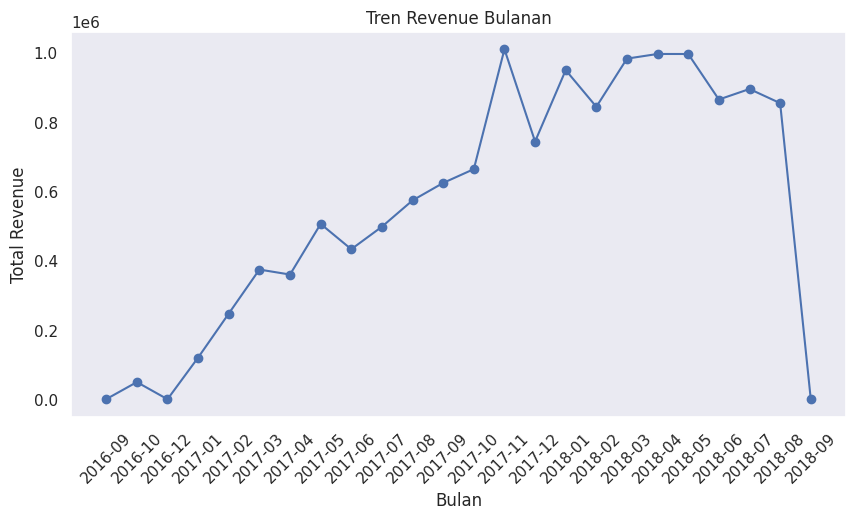

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['month'], monthly_sales['price'], marker='o')
plt.title('Tren Revenue Bulanan')
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2: Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir? visualization dan explanatpry nya seperti apa

In [15]:
customer_freq = df.groupby('customer_id')['order_id'].count().reset_index()
customer_freq.columns = ['customer_id', 'frequency']

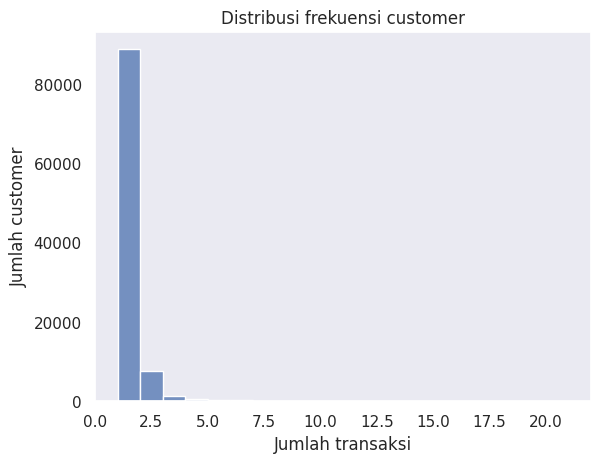

In [16]:
sns.histplot(customer_freq['frequency'], bins=20)
plt.title('Distribusi frekuensi customer')
plt.xlabel('Jumlah transaksi')
plt.ylabel('Jumlah customer')
plt.show()

In [17]:
customer_freq.head()

,customer_id,frequency
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


**Insight:**
- Berdasarkan visualisasi distribusi pembelian pelanggan, terlihat bahwa sebagian besar pelanggan hanya melakukan satu kali transaksi. Distribusi data sangat condong ke sebelah kiri (right-skewed), yang menunjukan bahwa pelanggan berada pada kategori pembelian rendah. hanya sebagai pelanggan yang melakukan pembelian lebih dari satu kali. Hal ini mengindikasikan bahwa tingkat retensi pelanggan masi rendah, dimana sebagian besar pelanggan tidak melakukan pembelian ulang setelah transaksi pertama. Namun terdapat kelompok kecil pelanggan dengan frekuensi pembelian yang lebih tinggi yang berpotensi menjadi pelanggan loyal dan memberikan kontribusi signifikan terhadap revenue perusahaan. Oleh karena itu, perusahaan perlu menerapkan strategi retensi pelanggan seperti program loyakitasm diskon khusus, atau personalisasi promosi meningkatkan frekuensi pembelian pelanggan.


## Analisis Lanjutan (Opsional)

RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian, yaitu berdasarkan waktu terakhir pembelian (Recency), frekuensi pembelian (frequency), dan total pengeluaran

In [18]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [19]:
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

In [20]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80
1,000161a058600d5901f007fab4c27140,414,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90
4,000379cdec625522490c315e70c7a9fb,154,1,93.00


<Axes: >

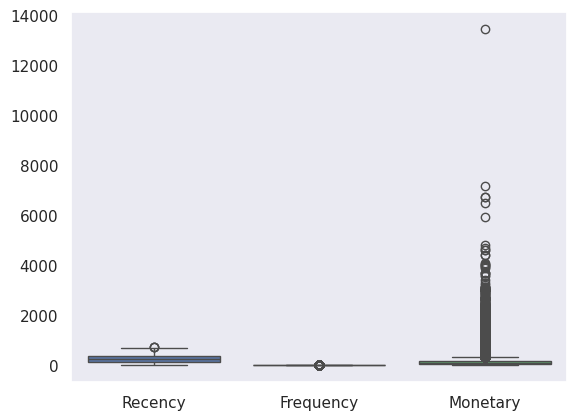

In [21]:
sns.boxplot(data=rfm[['Recency','Frequency','Monetary']])

In [22]:
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].sum(axis=1)
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80,2,1,3,6
1,000161a058600d5901f007fab4c27140,414,1,54.90,1,1,2,4
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99,1,1,4,6
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90,1,1,3,5
4,000379cdec625522490c315e70c7a9fb,154,1,93.00,3,1,3,7


In [25]:

df = pd.read_csv("main_data.csv")

# ambil kolom penting aja
cols = [
    'order_id',
    'customer_id',
    'order_purchase_timestamp',
    'price',
    'customer_state'
]
df = df[cols]

df = pd.read_csv("main_data.csv")

# ambil kolom penting aja
cols = [
    'order_id',
    'customer_id',
    'order_purchase_timestamp',
    'price',
    'customer_state'
]
df = df[cols]

# filter 1 tahun
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df = df[df['order_purchase_timestamp'].dt.year == 2018]

# sampling
df = df.sample(n=min(10000, len(df)), random_state=42)


# filter 1 tahun
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df = df[df['order_purchase_timestamp'].dt.year == 2018]

# sampling
df = df.sample(n=min(5000, len(df)), random_state=42)



Dataset yang digunakan merupakan subset dari data asli sebanyak 5000 data yang dipilih secara acak untuk menjaga efisiensi pemrosesan dan performa visualisasi tanpa mengurangi representasi pola makan dalam data

In [24]:
# simpan file
df.to_csv('main_data.csv', index=False)

# download file
from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- Conclution pertanyaan 1 : Performa penjualan dan revenue perusahaan menunjukkan pola fluktuatif dari bulan ke bulan dengan kecenderungan meningkat pada periode tertentu. Peningkatan revenue cenderung sejalan dengan jumlah transaksi yang menunjukkan bahwa volume order menjadi faktor utama dalam pertumbuhan pendapatan.

- Conclution pertanyaan 2 : Distribusi frekuensi pelanggan menunjukkan bahwa sebagian besar pelanggan hanya melakukan satu kali transaksi. Hal ini teridentifikasi bahwa tingkat retensi pelanggan masih rendah.

Namun demikian, terdapat sebagian kecil pelanggan dengan frekuensi pembelian tinggi yang berkontribusi signifikan terhadap revenue perusahaan. Oleh karena itu, perusahaan disarankan untuk fokus pada strategi peningkatan jumlah transaksi serta memperkuat retensi pelanggan melalui program loyalitas dan promosi guma meningkatkan performa bisnis.
